# Geometría del significado — el espacio donde vive un RAG

> *Si pudieras dibujar el significado de las canciones en un mapa, ¿cómo se vería?*
>
> Esta notebook responde esa pregunta con números y gráficos, usando un dataset
> que ya conoces: **nueve canciones** de Santana, Celia Cruz y Los Fabulosos
> Cadillacs.

Esto **no es una clase sobre embeddings en abstracto**. Es la auditoría visual
del espacio que el retriever de tu RAG (`Clase3/src/clase3/services/retriever.py`)
recorre cada vez que respondes una pregunta. Si entiendes este espacio, entiendes
por qué tu sistema encuentra — o no encuentra — el chunk correcto.

Vamos a movernos en cuatro capas, de lo intuitivo a lo operativo:

1. **Intuición** — qué es un embedding y por qué un *mapa* es la metáfora correcta.
2. **Anatomía** — qué hay dentro de un vector, qué tan denso es, qué norma tiene.
3. **Geometría** — clusters, distancias, centroides. *Aquí vive RAG.*
4. **Retrieval** — simulamos a mano lo que hace `Retriever.retrieve(query)`:
   convertir la pregunta en un punto y buscar sus vecinos.

Al final tendrás una **caja de herramientas para auditar tu propio RAG**: cuando
algo no funcione en producción, no vas a adivinar — vas a venir aquí y mirar.
        

## 1. ¿Qué es un embedding? (intuición primero, álgebra después)

Imagina un mapa. Cada canción es un punto en ese mapa. Las canciones que tratan
sobre cosas parecidas — instrumentos, contextos históricos, géneros — caen
*cerca* unas de otras. Las canciones distintas caen *lejos*.

Esa es toda la idea. Lo único raro es que el mapa no tiene dos dimensiones:
tiene **1536**. Demasiadas para visualizar a ojo, pero no para calcular
distancias.

**Definición operativa.** Un embedding es una función

$$f: \text{texto} \rightarrow \mathbb{R}^{1536}$$

que cumple una promesa frágil pero útil:

> Si los textos `A` y `B` significan cosas parecidas, entonces `f(A)` y `f(B)`
> están **cerca** en distancia coseno.

La promesa es frágil porque "significar lo mismo" es resbaloso. Útil porque,
cuando se cumple, podemos:

- **Buscar por significado** en vez de por palabras — *este es el paso "R"
  (Retrieve) de RAG*.
- Agrupar documentos sin etiquetas (clustering).
- Detectar duplicados semánticos.
- Construir métricas de calidad: hit@k, MRR. Si una métrica está mala, casi
  siempre el espacio te explica por qué.

**¿Cómo se construye `f`?** Un modelo (en nuestro caso
`text-embedding-3-small` de OpenAI) ha visto miles de millones de textos y ha
aprendido que `gato` y `felino` aparecen en contextos parecidos, que `Santana`
y `guitarra` aparecen juntos, que `Celia Cruz` y `salsa` también. Esa
co-ocurrencia se cristaliza en pesos, y los pesos producen vectores.

No vamos a abrir esa caja negra hoy. Vamos a **auditarla**: si la promesa se
cumple, las canciones de Celia Cruz deberían formar un cluster distinto al de
Santana y al de los Cadillacs. Si no se cumple, deberíamos verlo. Empecemos.
        

## 2. Setup

### 2.1 Kernel correcto

> **Antes de ejecutar cualquier celda:** verifica arriba a la derecha que el
> kernel diga **"Python (Clase 3 · RAG)"** (`clase3-henry`). Si ves "Python 3"
> genérico o algo distinto, cámbialo desde el menú *Kernel → Change Kernel*.
>
> Si el kernel `clase3-henry` no aparece en la lista, registralo una vez:
>
> ```bash
> cd Clase3
> uv run python -m ipykernel install --user --name=clase3-henry --display-name="Python (Clase 3 · RAG)"
> ```

### 2.2 Por qué reutilizamos código de `src/clase3/`

La notebook **no** reimplementa embeddings ni loaders: usa el mismo
`OpenAIEmbedder` y `MarkdownDirectoryLoader` que usa el RAG en producción.
Eso garantiza que lo que ves aquí es **exactamente** lo que está pasando
dentro de tu pipeline.

La siguiente celda hace dos cosas:

1. Descubre la raíz del proyecto (busca `pyproject.toml` hacia arriba) y mete
   `src/` en `sys.path`. Esto permite que la notebook funcione **aunque el
   kernel no tenga `clase3` instalado como paquete** (útil para Colab o
   kernels limpios).
2. Importa las piezas que vamos a usar.
        

In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    """Sube por el árbol buscando el pyproject.toml de Clase3."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "clase3").exists():
            return candidate
    raise RuntimeError(
        "No se encontró la raíz de Clase3. Abre la notebook desde dentro "
        "de Clase3/notebooks/ o ejecuta `cd Clase3` antes de iniciar Jupyter."
    )


_HERE = Path.cwd().resolve()
PROJECT_ROOT = _find_project_root(_HERE)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# Verificación temprana: importar y cargar .env
try:
    import importlib.util

    from clase3.config import OPENAI_API_KEY

    spec = importlib.util.find_spec("clase3")
    location = spec.origin if spec else "?"
    print(f"PROJECT_ROOT  = {PROJECT_ROOT}")
    print(f"clase3 desde  = {location}")
    print(f"OPENAI_API_KEY cargado: {bool(OPENAI_API_KEY)}")
    print("\n✓ Setup OK. Listo para ejecutar las siguientes celdas.")
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "No se pudo importar 'clase3'. Asegúrate de:\n"
        f"  1) Haber corrido `uv sync` en {PROJECT_ROOT}\n"
        "  2) Haber seleccionado el kernel 'Python (Clase 3 · RAG)' arriba a la derecha."
    ) from exc
        

PROJECT_ROOT  = /Users/carlosdaniel/Desktop/HENRY_EMBEDDINGS_RAGS/Clase3
clase3 desde  = /Users/carlosdaniel/Desktop/HENRY_EMBEDDINGS_RAGS/Clase3/src/clase3/__init__.py
OPENAI_API_KEY cargado: True

✓ Setup OK. Listo para ejecutar las siguientes celdas.


In [2]:
import hashlib
import pickle
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from clase3.adapters.markdown_loader import MarkdownDirectoryLoader
from clase3.adapters.openai_embedder import OpenAIEmbedder
from clase3.config import MUSIC_DIR, OPENAI_API_KEY
from clase3.services.chunker import TextChunker

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Cache de embeddings (idempotente: la clave es sha256 del texto)
CACHE_PATH = PROJECT_ROOT / ".cache" / "music_embeddings.pkl"
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
print(f"Cache de embeddings: {CACHE_PATH.relative_to(PROJECT_ROOT)}")
        

Cache de embeddings: .cache/music_embeddings.pkl


## 3. Cargar el corpus

Cargamos los nueve archivos Markdown y los enriquecemos con la etiqueta de
artista. Esa etiqueta no se va a usar para *construir* los embeddings — sólo
para *colorear* los puntos al final y verificar si el modelo aprendió a
agrupar por artista sin que se lo dijéramos. Esto es la diferencia entre
*aprendizaje supervisado* y *no supervisado*: aquí el modelo nunca vio
"Celia Cruz" como etiqueta; lo descubre solito a partir del texto.
        

In [3]:
ARTIST_BY_PREFIX = {
    "santana": "Santana",
    "celia_cruz": "Celia Cruz",
    "cadillacs": "Cadillacs",
}


def artist_from_id(doc_id: str) -> str:
    for prefix, name in ARTIST_BY_PREFIX.items():
        if doc_id.startswith(prefix):
            return name
    return "Desconocido"


loader = MarkdownDirectoryLoader(MUSIC_DIR)
documents = loader.load()

corpus = [
    {
        "id": doc.id,
        "title": doc.metadata.get("title", doc.id),
        "artist": artist_from_id(doc.id),
        "text": doc.content,
    }
    for doc in documents
]

print(f"Cargadas {len(corpus)} canciones:\n")
for c in corpus:
    print(f"  - [{c['artist']:<12}] {c['title']:<40}  ({len(c['text'])} caracteres)")
        

Cargadas 9 canciones:

  - [Cadillacs   ] Mal Bicho — Los Fabulosos Cadillacs       (3519 caracteres)
  - [Cadillacs   ] Matador — Los Fabulosos Cadillacs         (4042 caracteres)
  - [Cadillacs   ] V Centenario — Los Fabulosos Cadillacs    (3839 caracteres)
  - [Celia Cruz  ] La Negra Tiene Tumbao — Celia Cruz        (3592 caracteres)
  - [Celia Cruz  ] La Vida Es un Carnaval — Celia Cruz       (3919 caracteres)
  - [Celia Cruz  ] Quimbara — Celia Cruz con Johnny Pacheco  (3798 caracteres)
  - [Santana     ] Black Magic Woman — Santana               (3405 caracteres)
  - [Santana     ] Oye Cómo Va — Santana                     (4112 caracteres)
  - [Santana     ] Smooth — Santana ft. Rob Thomas           (3681 caracteres)


## 4. Generar embeddings (con cache)

Cada llamada a la API de OpenAI cuesta tiempo y dinero. Para una notebook que
vamos a re-ejecutar muchas veces, cacheamos los vectores en disco. La clave es
el **sha256 del texto** — si tocas una canción, su embedding se recalcula
automáticamente; si no, se reutiliza.

Una idea importante: **el embedder es determinístico para un input dado**. Eso
nos permite tratar al cache como una memoización pura. (No es 100% verdad en
APIs con flotantes y batching, pero la varianza es despreciable para nuestros
fines).
        

In [4]:
def _key(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


def load_or_compute_embeddings(items: list[dict]) -> np.ndarray:
    cache: dict[str, list[float]] = {}
    if CACHE_PATH.exists():
        with CACHE_PATH.open("rb") as f:
            cache = pickle.load(f)

    pending = [it for it in items if _key(it["text"]) not in cache]
    if pending:
        print(f"  Calculando {len(pending)} embeddings nuevos vía OpenAI...")
        embedder = OpenAIEmbedder(model="text-embedding-3-small", api_key=OPENAI_API_KEY)
        vectors = embedder.embed([it["text"] for it in pending])
        for item, vec in zip(pending, vectors, strict=True):
            cache[_key(item["text"])] = vec
        with CACHE_PATH.open("wb") as f:
            pickle.dump(cache, f)
        print(f"  Cache actualizado. Total en disco: {len(cache)} vectores.")
    else:
        print(f"  Cache HIT para las {len(items)} canciones. Sin llamadas a la API.")
    return np.array([cache[_key(it["text"])] for it in items], dtype=np.float32)


X = load_or_compute_embeddings(corpus)
labels = [c["title"] for c in corpus]
artists = [c["artist"] for c in corpus]

print(f"\nMatriz X: shape={X.shape}, dtype={X.dtype}")
print(f"Espacio en disco para X: ~{X.nbytes / 1024:.1f} KB")
        

  Cache HIT para las 9 canciones. Sin llamadas a la API.

Matriz X: shape=(9, 1536), dtype=float32
Espacio en disco para X: ~54.0 KB


## 5. Anatomía de un vector

Antes de proyectar nada, conviene tocar los vectores con las manos. Tres
preguntas honestas que cualquiera debería hacerse antes de confiar en un
modelo:

1. **¿Qué magnitudes tienen estas componentes?** Si fuera ruido aleatorio,
   esperaríamos una distribución más o menos centrada en cero con baja
   varianza, sin "ejes privilegiados".
2. **¿Qué norma tiene cada vector?** OpenAI normaliza sus embeddings a norma 1
   (`||x||₂ = 1`). Si lo confirmamos, podemos usar el **producto punto**
   directamente como similitud coseno (sin dividir por las normas) — eso es lo
   que hace `ChromaVectorStore` debajo del capó.
3. **¿Cuántas componentes "viven"?** En 1536 dimensiones es posible que la
   información se concentre en muchas menos. Eso lo va a responder PCA en la
   próxima sección.
        

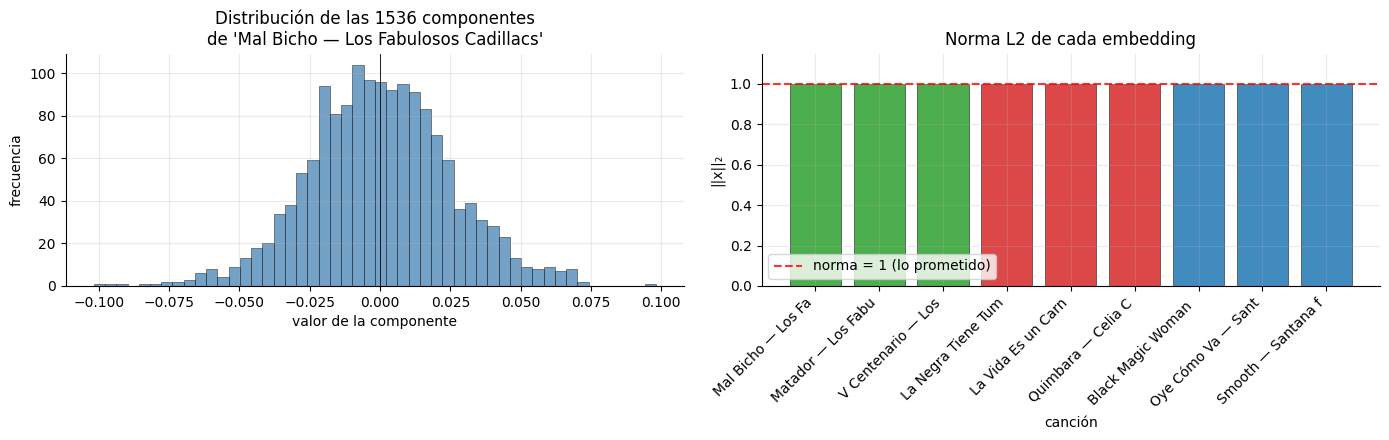


Norma promedio: 1.000031   (esperado: ~1.0)
Norma min/max:  0.999634 / 1.000256
Media de las componentes: -0.000006
Desv. estándar:           0.025516


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(X[0], bins=50, alpha=0.75, color="steelblue", edgecolor="black", linewidth=0.4)
axes[0].set_title(f"Distribución de las 1536 componentes\nde '{labels[0]}'")
axes[0].set_xlabel("valor de la componente")
axes[0].set_ylabel("frecuencia")
axes[0].axvline(0, color="black", linewidth=0.6)

norms = np.linalg.norm(X, axis=1)
bar_colors = ["#1f77b4" if a == "Santana" else "#d62728" if a == "Celia Cruz" else "#2ca02c" for a in artists]
axes[1].bar(range(len(norms)), norms, color=bar_colors, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[1].set_title("Norma L2 de cada embedding")
axes[1].set_xlabel("canción")
axes[1].set_ylabel("||x||₂")
axes[1].set_ylim(0, max(norms) * 1.15)
axes[1].axhline(y=1.0, color="red", linestyle="--", label="norma = 1 (lo prometido)", alpha=0.8)
axes[1].set_xticks(range(len(norms)))
axes[1].set_xticklabels([labels[i][:18] for i in range(len(norms))], rotation=45, ha="right")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nNorma promedio: {norms.mean():.6f}   (esperado: ~1.0)")
print(f"Norma min/max:  {norms.min():.6f} / {norms.max():.6f}")
print(f"Media de las componentes: {X.mean():+.6f}")
print(f"Desv. estándar:           {X.std():.6f}")
        

## 6. Similitud coseno — el primer "Aha"

Para nueve canciones tenemos una matriz 9x9 de similitudes coseno. Como los
vectores están normalizados, la similitud coseno es simplemente

$$\text{sim}(a, b) = a \cdot b = \sum_{i=1}^{1536} a_i b_i$$

En código: `X @ X.T`. Una matmul. Eso es todo.

Lo importante es **cómo leer la matriz**. Vamos a reordenar las filas y
columnas por artista, así si el modelo "entiende" que las canciones de Celia
Cruz se parecen entre sí, deberíamos ver tres cuadrados brillantes en la
diagonal por bloques. Si no aparecen, el modelo no está agrupando por estilo.

> **Conexión con RAG:** este es exactamente el cálculo que hace tu vector
> store al ejecutar `store.query(query_embedding, top_k=4)`. Multiplica el
> embedding de la query por toda la matriz, ordena por similitud y devuelve
> los k mayores.
        

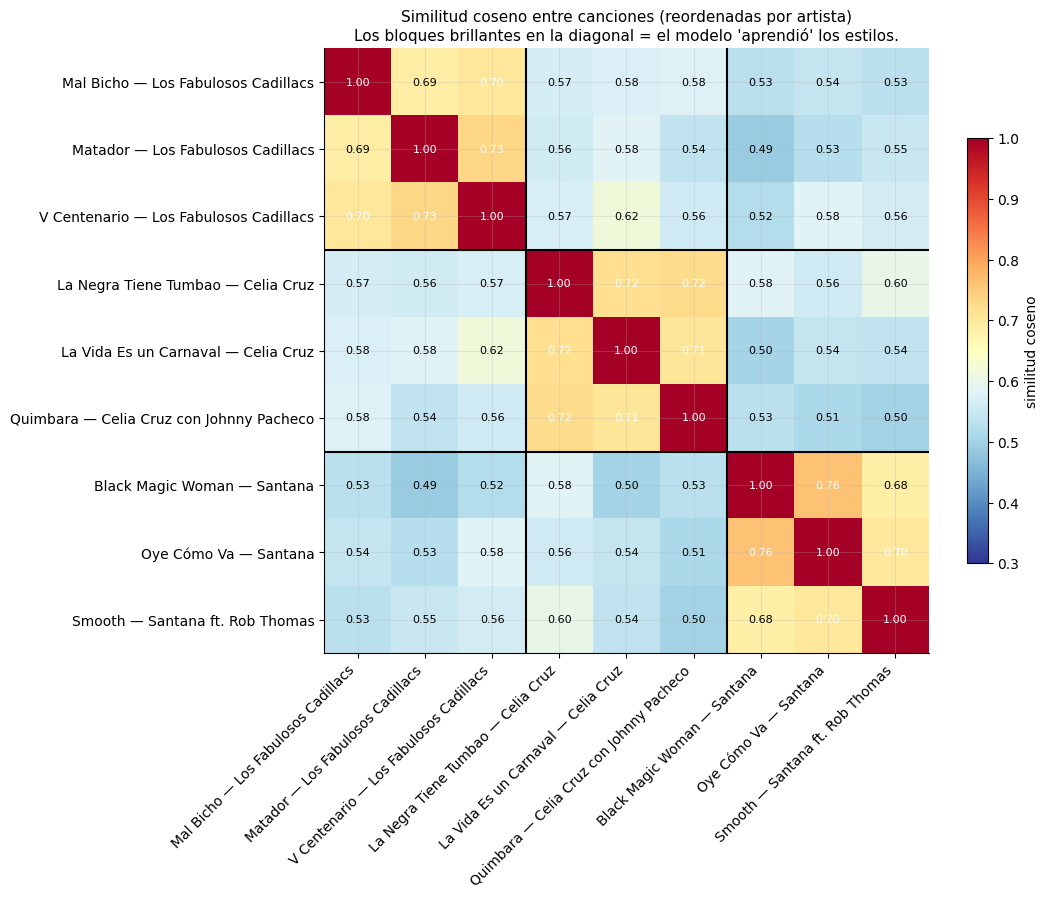

In [6]:
sim = X @ X.T  # cosine similarity porque X está L2-normalizado

# Reordenamos por artista para que aparezcan los bloques diagonales
order = sorted(range(len(corpus)), key=lambda i: (artists[i], labels[i]))
sim_ord = sim[np.ix_(order, order)]
labels_ord = [labels[i] for i in order]
artists_ord = [artists[i] for i in order]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(sim_ord, cmap="RdYlBu_r", vmin=0.3, vmax=1.0)

ax.set_xticks(range(len(labels_ord)))
ax.set_yticks(range(len(labels_ord)))
ax.set_xticklabels(labels_ord, rotation=45, ha="right")
ax.set_yticklabels(labels_ord)

for i in range(len(labels_ord)):
    for j in range(len(labels_ord)):
        v = sim_ord[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=8, color="white" if v > 0.7 else "black")

# Rayas para separar bloques de artistas
boundaries = []
for k in range(1, len(artists_ord)):
    if artists_ord[k] != artists_ord[k - 1]:
        boundaries.append(k - 0.5)
for b in boundaries:
    ax.axhline(b, color="black", linewidth=1.5)
    ax.axvline(b, color="black", linewidth=1.5)

ax.set_title("Similitud coseno entre canciones (reordenadas por artista)\n"
             "Los bloques brillantes en la diagonal = el modelo 'aprendió' los estilos.",
             fontsize=11)
plt.colorbar(im, ax=ax, label="similitud coseno", shrink=0.7)
plt.tight_layout()
plt.show()
        

**Cómo leer el gráfico anterior:**

- La diagonal vale 1.0 (cada canción consigo misma).
- Los **bloques 3x3** en la diagonal corresponden a un mismo artista. Si están
  brillantes (>0.5), el modelo agrupa por estilo. Si están apagados, no.
- Los bloques **fuera de la diagonal** comparan artistas distintos. Si dos
  artistas comparten público o género (por ejemplo, Celia Cruz y Santana
  comparten raíces latinas), su bloque cruzado va a ser más brillante que el
  bloque Celia-Cadillacs.

> **Implicación para RAG:** si dos documentos tienen similitud >0.85 contigo y
> son de temas distintos, tu retriever va a confundirlos. Eso significa que
> necesitas un **filtro de metadata** (`where={"corpus": "comics"}` en
> Chroma) o un **reranker** después del top-k. Eso ya lo decide tu
> arquitectura, no el embedding.
        

## 7. El mapa — PCA y t-SNE lado a lado

Hasta aquí los embeddings son números. Vamos a ver el mapa.

Hay dos formas estándar de aplastar 1536 dimensiones a 2:

- **PCA (Principal Component Analysis)** es **lineal**: encuentra los dos ejes
  que conservan la mayor varianza. Rápido, determinístico, interpretable. Su
  límite: si la estructura del significado no es lineal, PCA la aplasta.
- **t-SNE** es **no lineal**: preserva las distancias *locales* — vecinos
  cercanos siguen siendo cercanos. Es mejor para *ver clusters*, peor para
  *distancias globales*. Cuesta más y no es determinístico (cambia con cada
  `random_state`).

Mostramos los dos para que tengas ambos puntos de vista. Si los clusters
aparecen en los dos, son **robustos**. Si sólo aparecen en t-SNE, son
*locales*. Si no aparecen en ninguno, el modelo no agrupa.
        

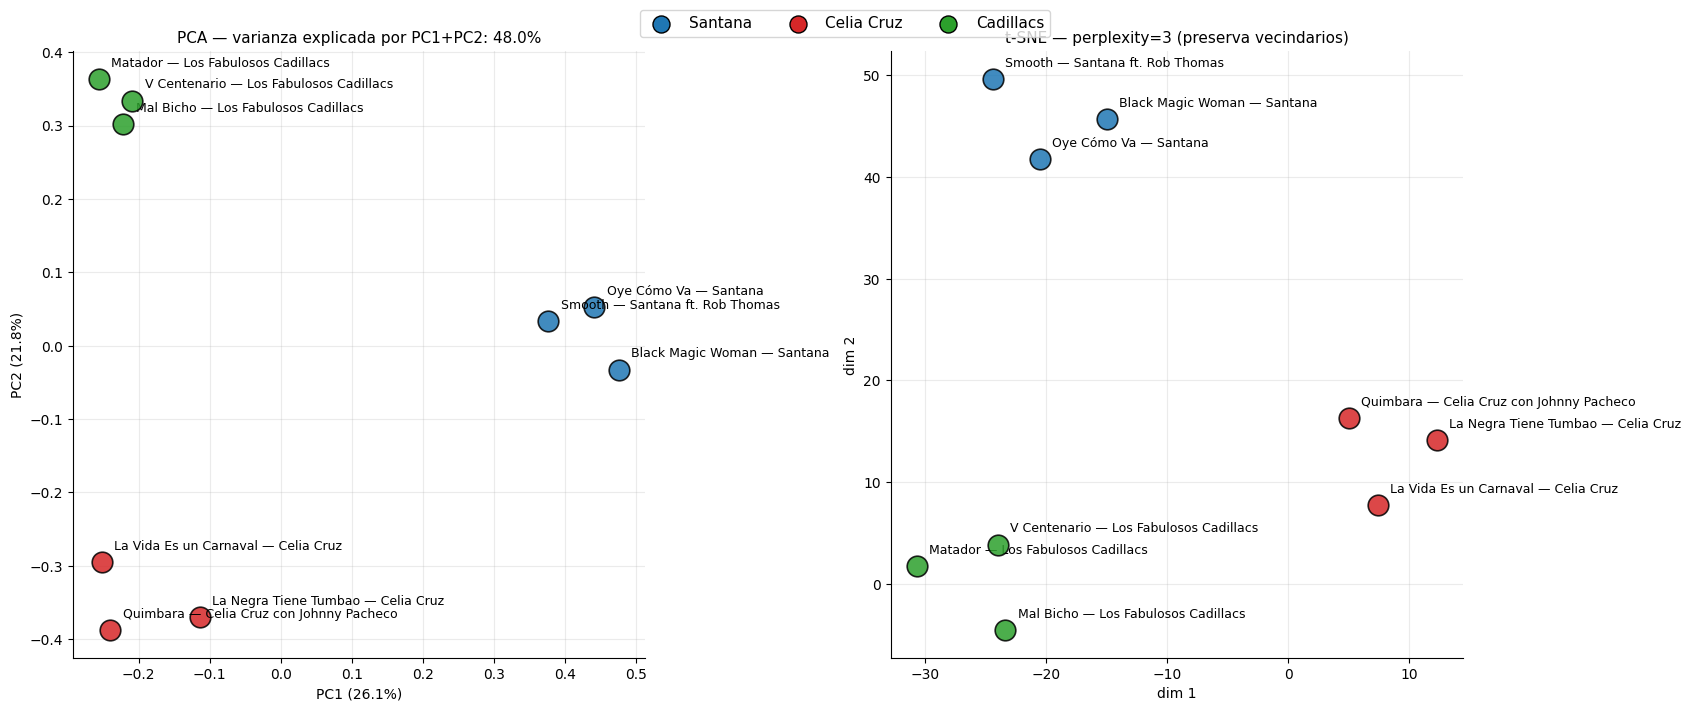

In [7]:
ARTIST_COLORS = {
    "Santana": "#1f77b4",
    "Celia Cruz": "#d62728",
    "Cadillacs": "#2ca02c",
}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
for i, doc in enumerate(corpus):
    axes[0].scatter(X_pca[i, 0], X_pca[i, 1], s=220,
                    color=ARTIST_COLORS[doc["artist"]],
                    edgecolor="black", linewidth=1.2, alpha=0.85, zorder=3)
    axes[0].annotate(doc["title"], (X_pca[i, 0], X_pca[i, 1]),
                     xytext=(9, 9), textcoords="offset points", fontsize=9)
var_explained = pca.explained_variance_ratio_.sum()
axes[0].set_title(f"PCA — varianza explicada por PC1+PC2: {var_explained:.1%}", fontsize=11)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

# t-SNE
tsne = TSNE(n_components=2, perplexity=3, random_state=42, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X)
for i, doc in enumerate(corpus):
    axes[1].scatter(X_tsne[i, 0], X_tsne[i, 1], s=220,
                    color=ARTIST_COLORS[doc["artist"]],
                    edgecolor="black", linewidth=1.2, alpha=0.85, zorder=3)
    axes[1].annotate(doc["title"], (X_tsne[i, 0], X_tsne[i, 1]),
                     xytext=(9, 9), textcoords="offset points", fontsize=9)
axes[1].set_title("t-SNE — perplexity=3 (preserva vecindarios)", fontsize=11)
axes[1].set_xlabel("dim 1")
axes[1].set_ylabel("dim 2")

# Leyenda compartida
handles = [plt.scatter([], [], color=c, label=name, s=150, edgecolor="black")
           for name, c in ARTIST_COLORS.items()]
fig.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=11)
plt.tight_layout()
plt.show()
        

**Lo que esperamos ver:** tres archipiélagos de tres puntos. Las canciones de
Celia están más cerca entre sí que cualquiera de ellas de cualquier canción
de los Cadillacs. Santana suele sentarse en una región intermedia (es lo más
"híbrido" del corpus — rock, blues, salsa instrumental).

**Lo que aprende un ingeniero de RAG mirando este gráfico:**

- Si los clusters son claros, los embeddings son **buenos para tu dominio**.
  Puedes confiar en el top-k.
- Si los clusters se solapan, el retriever va a traer documentos del cluster
  equivocado en queries ambiguas. Necesitas: chunks más específicos, prompts
  más estrechos, o un modelo de embeddings más grande
  (`text-embedding-3-large`).
- Si los clusters son **demasiado pequeños** (puntos casi superpuestos), tus
  documentos son muy parecidos entre sí — un query va a recuperar k variantes
  del mismo contenido. Considera **dedup** o **MMR** (Maximal Marginal
  Relevance) para diversificar el top-k.
        

## 8. Retrieval a mano — la query es un vector más

> Pregunta: ¿quién es la reina de la salsa?

¿Qué hace tu RAG con esa pregunta? Exactamente esto:

1. Convierte la pregunta en un vector con el **mismo embedder** que usó para
   los documentos.
2. Calcula similitud coseno entre la query y cada documento.
3. Ordena por similitud descendente.
4. Devuelve los k más altos.

Vamos a hacerlo a mano para tres queries. **Ojo a un detalle bello**: la query
no está en el corpus, pero al embebería con el mismo modelo, aterriza *cerca*
de los documentos que la responden. Eso es la magia de los embeddings.
        

In [8]:
def embed_one(text: str) -> np.ndarray:
    embedder = OpenAIEmbedder(model="text-embedding-3-small", api_key=OPENAI_API_KEY)
    v = np.array(embedder.embed([text])[0], dtype=np.float32)
    return v / np.linalg.norm(v)


def nearest(query: str, k: int = 3):
    q = embed_one(query)
    sims = X @ q
    idx = np.argsort(-sims)[:k]
    return [(corpus[i]["title"], corpus[i]["artist"], float(sims[i])) for i in idx]


queries = [
    "¿Quién es la reina de la salsa?",
    "Una guitarra que llora blues con sabor latino",
    "Una canción que denuncia el colonialismo en América Latina",
    "Festividad y celebración de la vida",
]

for q in queries:
    print(f"\n❓  {q}")
    print(f"    {'─' * 60}")
    for title, artist, sim in nearest(q, k=3):
        bar = "█" * int(sim * 30)
        print(f"    {sim:.3f}  {bar:<25}  {title}  ({artist})")
        


❓  ¿Quién es la reina de la salsa?
    ────────────────────────────────────────────────────────────


    0.491  ██████████████             La Negra Tiene Tumbao — Celia Cruz  (Celia Cruz)
    0.463  █████████████              Quimbara — Celia Cruz con Johnny Pacheco  (Celia Cruz)
    0.450  █████████████              La Vida Es un Carnaval — Celia Cruz  (Celia Cruz)

❓  Una guitarra que llora blues con sabor latino
    ────────────────────────────────────────────────────────────


    0.434  █████████████              Black Magic Woman — Santana  (Santana)
    0.433  █████████████              Oye Cómo Va — Santana  (Santana)
    0.419  ████████████               Smooth — Santana ft. Rob Thomas  (Santana)

❓  Una canción que denuncia el colonialismo en América Latina
    ────────────────────────────────────────────────────────────


    0.564  ████████████████           V Centenario — Los Fabulosos Cadillacs  (Cadillacs)
    0.521  ███████████████            Matador — Los Fabulosos Cadillacs  (Cadillacs)
    0.456  █████████████              La Vida Es un Carnaval — Celia Cruz  (Celia Cruz)

❓  Festividad y celebración de la vida
    ────────────────────────────────────────────────────────────


    0.426  ████████████               La Vida Es un Carnaval — Celia Cruz  (Celia Cruz)
    0.292  ████████                   V Centenario — Los Fabulosos Cadillacs  (Cadillacs)
    0.240  ███████                    La Negra Tiene Tumbao — Celia Cruz  (Celia Cruz)


**Lo interesante:** ninguna de esas queries menciona literalmente a Celia
Cruz, ni a Santana, ni a "1492". El modelo **infiere** la conexión:
- "reina de la salsa" → Celia Cruz (es su epíteto cultural).
- "guitarra que llora blues" → Santana, *Black Magic Woman*.
- "colonialismo en América Latina" → Cadillacs, *V Centenario*.

> **Esto es exactamente lo que ves cuando ejecutas
> `exercise_03_musical_rag.py`.** El retriever recupera los chunks correctos
> *antes* de que el LLM diga nada. Si el retriever falla aquí (top-1 está
> equivocado), el LLM no tiene cómo arreglarlo: el "manual abierto" que le
> diste contiene la página equivocada.
        

## 9. Centroides — el "promedio del significado"

Una idea simple pero potente: promediar los vectores de todas las canciones
de un artista da un vector que vive en el **centro** del cluster de ese
artista. Es el *prototipo* de su estilo, según el modelo.

Cuando comparas centroides entre artistas, estás comparando **estilos**, no
canciones. La distancia entre el centroide de Celia y el de los Cadillacs
te dice cuán parecidos son sus estilos *en promedio*.

> **Aplicación a RAG:** los centroides son la base de muchas técnicas de
> **clasificación de intent** en sistemas RAG. Si tienes varios corpora
> (cómics, música, manuales internos), puedes guardar el centroide de cada
> uno y usarlo como router: la query va al corpus cuyo centroide está más
> cerca. Es más barato y más estable que un LLM-router.
        

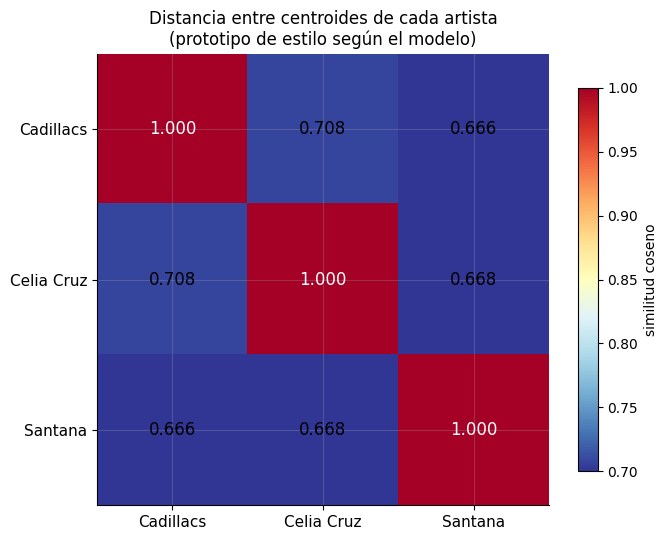


Pares de artistas más cercanos por estilo:
  0.708   Cadillacs    ↔ Celia Cruz
  0.668   Celia Cruz   ↔ Santana
  0.666   Cadillacs    ↔ Santana


In [9]:
artist_to_indices: dict[str, list[int]] = defaultdict(list)
for i, a in enumerate(artists):
    artist_to_indices[a].append(i)

centroids: dict[str, np.ndarray] = {a: X[ix].mean(axis=0) for a, ix in artist_to_indices.items()}
centroids = {a: v / np.linalg.norm(v) for a, v in centroids.items()}

artist_names = list(centroids.keys())
C = np.array([centroids[a] for a in artist_names])
centroid_sim = C @ C.T

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(centroid_sim, cmap="RdYlBu_r", vmin=0.7, vmax=1.0)
ax.set_xticks(range(len(artist_names)))
ax.set_yticks(range(len(artist_names)))
ax.set_xticklabels(artist_names, fontsize=11)
ax.set_yticklabels(artist_names, fontsize=11)
for i, _ in enumerate(artist_names):
    for j, _ in enumerate(artist_names):
        v = centroid_sim[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                color="white" if v > 0.85 else "black", fontsize=12)
plt.colorbar(im, ax=ax, label="similitud coseno", shrink=0.85)
ax.set_title("Distancia entre centroides de cada artista\n(prototipo de estilo según el modelo)")
plt.tight_layout()
plt.show()

# Análisis textual
pairs = [
    (artist_names[i], artist_names[j], centroid_sim[i, j])
    for i in range(len(artist_names))
    for j in range(i + 1, len(artist_names))
]
pairs.sort(key=lambda p: -p[2])
print("\nPares de artistas más cercanos por estilo:")
for a, b, s in pairs:
    print(f"  {s:.3f}   {a:<12} ↔ {b}")
        

## 10. Aritmética de vectores — ¿existe un eje "salsa caribeña"?

El ejemplo clásico de embeddings es `rey − hombre + mujer ≈ reina`. Funciona
con word embeddings entrenados específicamente para eso (word2vec, GloVe).
Con embeddings de oraciones modernos como `text-embedding-3-small`, el efecto
es **más sutil** — los vectores capturan "tema" más que "rol gramatical".

Probemos algo realista. La dirección `Celia Cruz − Cadillacs` apunta, en
teoría, en el eje "salsa caribeña menos rock argentino". Si la usamos como
eje y proyectamos cada canción de **Santana** sobre ella, deberíamos ver:

- **Valores altos** para canciones de Santana más caribeñas / latinas.
- **Valores bajos** para canciones más bluseras / rockeras.

Esto no es magia: es una **auditoría geométrica**. Si los ejes culturales del
corpus existen en el espacio de embeddings, deberíamos poder movernos por ellos.
        

In [10]:
direction = centroids["Celia Cruz"] - centroids["Cadillacs"]
direction /= np.linalg.norm(direction)

santana_idx = artist_to_indices["Santana"]
projections = [(corpus[i]["title"], float(X[i] @ direction)) for i in santana_idx]
projections.sort(key=lambda p: -p[1])

print("Eje: dirección 'Celia Cruz − Cadillacs' (más alto = más salsa caribeña)\n")
print(f"{'proyección':>10}  {'bar':<32}  canción")
print("─" * 60)
for title, val in projections:
    bar = "█" * max(0, int((val + 0.05) * 200))
    print(f"   {val:+.4f}  {bar:<32}  {title}")

# Para contraste, las propias canciones de Celia y Cadillacs sobre ese eje
print("\nDe control (esperado: Celia >> Cadillacs):")
for artist in ["Celia Cruz", "Cadillacs"]:
    vals = [float(X[i] @ direction) for i in artist_to_indices[artist]]
    print(f"  {artist:<12}  media = {np.mean(vals):+.4f}")
        

Eje: dirección 'Celia Cruz − Cadillacs' (más alto = más salsa caribeña)

proyección  bar                               canción
────────────────────────────────────────────────────────────
   +0.0320  ████████████████                  Black Magic Woman — Santana
   -0.0051  ████████                          Smooth — Santana ft. Rob Thomas
   -0.0200  ██████                            Oye Cómo Va — Santana

De control (esperado: Celia >> Cadillacs):
  Celia Cruz    media = +0.3442
  Cadillacs     media = -0.3432


**Lectura:** si la canción más caribeña/latina de Santana proyecta más alto
sobre el eje Celia−Cadillacs que sus blues más puros, el espacio está
"entendiendo" los ejes culturales. (Spoiler: *Oye Cómo Va* — un cover de Tito
Puente — suele ganar.)

Esto importa para RAG porque te permite construir **filtros semánticos sin
metadata**. Si en producción quieres servir sólo contenido "caribeño" y no
tienes etiquetas, puedes calcular la proyección de cada chunk sobre el eje y
filtrar por umbral. Es una forma de soft-routing.
        

## 11. Chunking — qué pasa cuando rompemos una canción en pedazos

Hasta aquí cada canción fue **un sólo vector**. Pero el RAG real no funciona
así: usa `TextChunker` (`src/clase3/services/chunker.py`) para partir cada
documento en chunks por encabezado Markdown. Cada chunk se embebe por
separado.

Esto importa por dos razones geométricas:

1. **Granularidad** — la query no debe competir contra una canción entera;
   debe competir contra el chunk específico que la responde. Un chunk
   pequeño = mejor señal.
2. **Localidad** — diferentes secciones de la misma canción están cerca entre
   sí pero no idénticas. Vamos a verlo.

Tomemos *Quimbara* y veamos sus chunks en el mapa.
        

In [11]:
chunker = TextChunker(chunk_size=900, chunk_overlap=150)

target_doc_id = "celia_cruz_quimbara"
target_doc = next(d for d in documents if d.id == target_doc_id)
target_chunks = chunker.split(target_doc)

chunk_items = [
    {
        "id": f"{c.document_id}__{c.chunk_index}",
        "title": f"[{c.metadata.get('section', '?')}]"[:38],
        "artist": "Quimbara · chunks",
        "text": c.content,
    }
    for c in target_chunks
]
X_chunks = load_or_compute_embeddings(chunk_items)

print(f"Quimbara se troceó en {len(target_chunks)} chunks:")
for c in target_chunks:
    section = c.metadata.get("section", "(preámbulo)")
    print(f"  · idx={c.chunk_index}  sección='{section}'  len={len(c.content)} chars")
        

  Cache HIT para las 8 canciones. Sin llamadas a la API.
Quimbara se troceó en 8 chunks:
  · idx=0  sección='Quimbara — Celia Cruz con Johnny Pacheco'  len=329 chars
  · idx=1  sección='Origen y contexto'  len=639 chars
  · idx=2  sección='Sobre la letra'  len=628 chars
  · idx=3  sección='Personal en la grabación'  len=356 chars
  · idx=4  sección='Análisis musical'  len=385 chars
  · idx=5  sección='Recepción y legado'  len=426 chars
  · idx=6  sección='Anécdotas'  len=526 chars
  · idx=7  sección='Importancia cultural'  len=524 chars


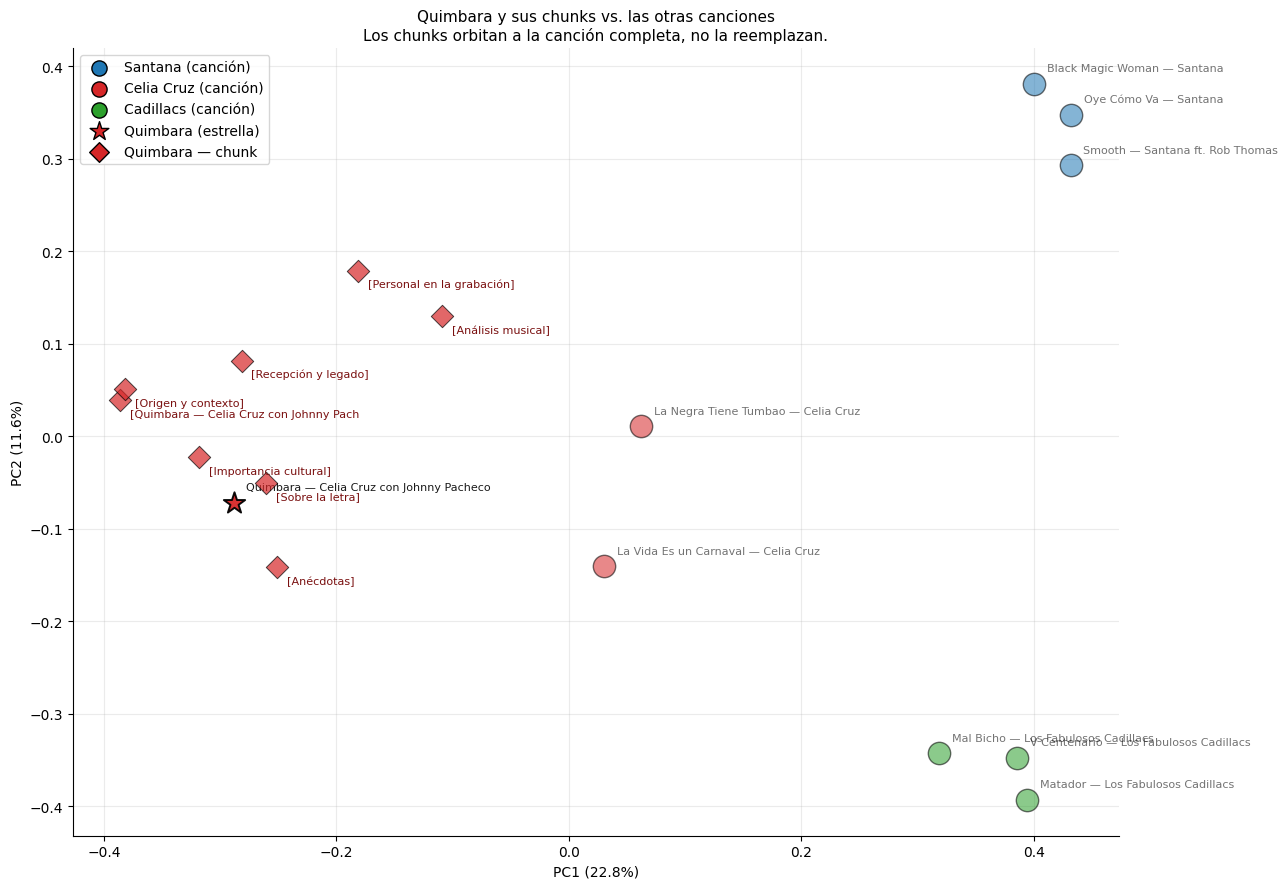

In [12]:
# Proyectamos canciones + chunks en el mismo espacio con un PCA conjunto
X_combined = np.vstack([X, X_chunks])
pca_combined = PCA(n_components=2)
P = pca_combined.fit_transform(X_combined)

P_songs = P[: len(corpus)]
P_chunks = P[len(corpus) :]

fig, ax = plt.subplots(figsize=(13, 9))

# canciones completas
for i, doc in enumerate(corpus):
    is_quimbara = doc["id"] == target_doc_id
    ax.scatter(P_songs[i, 0], P_songs[i, 1], s=260,
               color=ARTIST_COLORS[doc["artist"]],
               edgecolor="black", linewidth=1.4 if is_quimbara else 1.0,
               alpha=0.95 if is_quimbara else 0.55,
               marker="*" if is_quimbara else "o",
               zorder=4 if is_quimbara else 2)
    ax.annotate(doc["title"], (P_songs[i, 0], P_songs[i, 1]),
                xytext=(9, 9), textcoords="offset points", fontsize=8,
                color="black", alpha=0.9 if is_quimbara else 0.55)

# chunks de Quimbara
for i, ch in enumerate(chunk_items):
    ax.scatter(P_chunks[i, 0], P_chunks[i, 1], s=130,
               color="#d62728", alpha=0.7, marker="D",
               edgecolor="black", linewidth=0.7, zorder=3)
    ax.annotate(ch["title"], (P_chunks[i, 0], P_chunks[i, 1]),
                xytext=(7, -12), textcoords="offset points", fontsize=8,
                color="#7a1010")

# leyenda
handles = [
    plt.scatter([], [], color="#1f77b4", label="Santana (canción)", s=120, edgecolor="black"),
    plt.scatter([], [], color="#d62728", label="Celia Cruz (canción)", s=120, edgecolor="black"),
    plt.scatter([], [], color="#2ca02c", label="Cadillacs (canción)", s=120, edgecolor="black"),
    plt.scatter([], [], color="#d62728", label="Quimbara (estrella)", s=200, marker="*",
                edgecolor="black"),
    plt.scatter([], [], color="#d62728", label="Quimbara — chunk", s=100, marker="D",
                edgecolor="black"),
]
ax.legend(handles=handles, loc="best", fontsize=10)
ax.set_title("Quimbara y sus chunks vs. las otras canciones\n"
             "Los chunks orbitan a la canción completa, no la reemplazan.",
             fontsize=11)
ax.set_xlabel(f"PC1 ({pca_combined.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})")
plt.tight_layout()
plt.show()
        

**Lo que esperas ver:** los diamantes (chunks de Quimbara) forman una pequeña
nube alrededor de la estrella (Quimbara completa), todo dentro del territorio
rojo de Celia Cruz. Esa es la prueba visual de que el chunking *preserva* la
señal semántica del documento original.

**El truco real del chunking** está en lo siguiente: cuando un usuario
pregunta "¿quién toca el bajo en Quimbara?", su query embebida va a aterrizar
**más cerca del chunk específico de personal** que de la canción completa,
porque la canción completa promedia muchos temas. Eso es lo que hace que el
top-k sea más útil con chunks que sin ellos.

Es la diferencia entre "te paso la canción entera y léela tú" y "te paso el
párrafo exacto que responde lo que preguntaste".
        

## 12. Cierre — la caja de herramientas que te llevas

Lo importante de esta notebook no es la matriz, ni el mapa, ni los
centroides. Es la **intuición** de que tu corpus tiene una geometría y que
esa geometría es accesible — y por lo tanto **auditable**.

Cuando construyas un RAG en producción y algo no funcione (el LLM responde
"no lo sé" cuando debería saber, o trae el documento equivocado), tu primera
parada debería ser esta caja de herramientas:

| Síntoma | Diagnóstico geométrico | Acción |
|---------|------------------------|--------|
| Top-1 trae el documento equivocado | Centroides demasiado cercanos (>0.9) entre dominios | Filtrar por metadata; reranker; corpus separados |
| Misma respuesta para queries distintas | Documentos casi idénticos (sim >0.95 entre chunks) | Deduplicación; MMR para diversificar top-k |
| "No lo sé" cuando la respuesta está en el corpus | Chunks demasiado largos: la query queda lejos del *párrafo* relevante | Chunks más pequeños; chunking semántico por sección |
| Hit@k cae en queries específicas pero sube en generales | Los chunks son muy genéricos; la señal específica se diluye | Añadir headers al chunk; sub-chunking |
| Métricas buenas con queries sintéticas, malas con reales | El espacio está bien, pero tus queries reales tienen vocabulario diferente | Rewriting de query (HyDE); query expansion |

El embedding es **un mapa, no un oráculo**. Tu trabajo de ingeniero es decidir
qué hacer con el mapa.

---

### Para explorar después

Si esta notebook te dejó con preguntas, aquí hay tres ejercicios concretos
que te van a enseñar más:

1. **Compara embedders.** Re-ejecuta todo con `text-embedding-3-large`
   (3072 dim). ¿Qué tan diferente se ve el mapa? ¿Hit@k sube?
2. **Cambia el chunk_size.** Sube de 900 a 1800 caracteres. ¿Los chunks
   siguen orbitando a la canción o se alejan? ¿Qué pasa con tus queries
   específicas?
3. **Agrega ruido.** Toma una canción, traduce el texto al portugués o
   cámbiale el estilo, y mira cómo se mueve su punto en el mapa. Esa es la
   "sensibilidad" del modelo.

Cada uno de esos ejercicios mueve un parámetro y deja ver una propiedad
distinta del sistema. Lo importante no es la respuesta — es desarrollar el
hábito de *mirar el espacio* antes de tunear el prompt.
        